# Weissinger method

The present implementation focuses on **steady flows**, first with prescribed wake and later with free wake. Vortex lattice or panel methods are an extension of Weissinger method, with surface discretization of geometries.

## Project and (possible) future development



 A reasonable path towards a simple potential aerodynamic 3-dimensional code for streamlined bodies are:
- geometry definition
- options, like ground effect
- wake-body interactions, for complex configurations
- ...

while problems to be tackled are:
- steady flows with prescribed wakes (linear problem)
- steady flows with free wakes (position of the wave filaments are unknowns of the problem, that becomes non-linear)
- unsteady flows: generic vs. linearized problems, generic vs. periodic, time vs. Fourier domain,...
- ...

## Summary

**Import libraries.**

**Functions:** build geometry, to compute aerodynamic influence coefficients and build the linear system to be solved.

**Simulation:**
- define geometry, free-stream conditions, in or out ground-effect ($\texttt{ground_effect = True}$ or $\texttt{False}$) and other parameters
- build geometry
- build and solve the linear system

**Post-processing:**
- retrieve loads
- evaluate velocity and pressure (with Bernoulli's theorem) on $\texttt{z = 0}$ plane
- evaluate pressure shadow on ground projection of linear trajectories
- evaluate velocity field on a Trefftz-like plane in the wake

## Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

## Functions

Some useful functions

### Geometry: wing and prescribed wake

In [2]:
def build_wing_geometry( acs, chords, alphas, nspans, sym=False):
    """
    Inputs:
    ------
    x: stream-wise direction, y: chord-wise direction, z: normal direction (downwards)
    acs(3,n_vort+1): x,y,z coordinates of the reference point (here taken as the
                   "aerodynamic center" of each airfoils at .25 * chord from the
                   leading edge)
    chords, alphas: list of chords and aoas [rad]
    npsans(n_vort): # of spanwise vortices per span section
    sym: if True, define only a semi-wing and reflect it w.r.t. y-axis, y = 0

    Outputs:
    -------

    """

    x_ac = .0  # default (to be added as a function argument)

    #> If sym = False
    if sym == False:
        n_vortices = np.sum(nspans)
        n_points = n_vortices + 1
        n_nodes = 2 * n_points
        rr_le = np.zeros([3, n_points])
        rr_te = np.zeros([3, n_points])
        rr_le[0,0] = acs[0,0] - x_ac * chords[0] * np.cos(alphas[0])
        rr_le[1,0] = acs[1,0]
        rr_le[2,0] = acs[2,0] + x_ac * chords[0] * np.sin(alphas[0])
        rr_te[0,0] = acs[0,0] + (1.-x_ac) * chords[0] * np.cos(alphas[0])
        rr_te[1,0] = acs[1,0]
        rr_te[2,0] = acs[2,0] - (1.-x_ac) * chords[0] * np.sin(alphas[0])
        iy2 = 1
        #> rr
        for ispan in range(len(nspans)):
            iy1, iy2 = iy2, iy2 + nspans[ispan]
            ts = np.arange(1, nspans[ispan]+1) / nspans[ispan]
            dy = acs[1,ispan+1] - acs[1,ispan]
            ys  =  acs[1,ispan] + ts * dy
            xs  =  acs[0,ispan] + ts * ( acs[0,ispan+1] - acs[0,ispan] )
            zs  =  acs[2,ispan] + ts * ( acs[2,ispan+1] - acs[2,ispan] )
            cs  = chords[ispan] + ts * (chords[ispan+1] - chords[ispan])
            als = alphas[ispan] + ts * (alphas[ispan+1] - alphas[ispan])

            rr_le[0,iy1:iy2] = xs - x_ac * cs * np.cos(als)
            rr_le[1,iy1:iy2] = ys
            rr_le[2,iy1:iy2] = zs + x_ac * cs * np.sin(als)

            rr_te[0,iy1:iy2] = xs + (1-x_ac) * cs * np.cos(als)
            rr_te[1,iy1:iy2] = ys
            rr_te[2,iy1:iy2] = zs - (1-x_ac) * cs * np.sin(als)

        rr = np.block([rr_le, rr_te])

        #> ee
        ee = np.zeros([4, n_vortices], dtype=int)
        ee[0,:] = np.arange(n_points-1)
        ee[1,:] = np.arange(1,n_points)
        ee[2,:] = np.arange(n_points+1,2*n_points)
        ee[3,:] = np.arange(n_points  ,2*n_points-1)

    else:
        n_points = ( 2*np.sum(nspans) + 1 ) * 2
        ee = np.zeros([4, n_points])

    vsides = rr_te - rr_le
    vcenter = .5 * ( vsides[:,:-1] + vsides[:,1:] )

    #> Center of the panel
    cc = np.array([ np.mean(rr[:,ie], axis=1) for ie in list(ee.T)]).T

    # print('cc: ', cc);  print('vcenter:', vcenter)
    ac = cc - vcenter * .5
    cp = cc # + vcenter * ( .5 - x_ac )

    # print("ac: ", ac);  print("cp: ", cp)

    # print('ee: \n', ee)
    # print('rr: \n', rr)
    nor = np.array([ np.cross(rr[:, ie[2]]-rr[:, ie[0]], rr[:, ie[1]]-rr[:, ie[3]]) for ie in ee.T.tolist() ]).T
    # print("nor: ")
    # for n in np.arange(np.shape(nor)[1]):
    #     print(nor[:,n])

    nor = nor / np.linalg.norm(nor, axis=0, keepdims=True)

    return ac, cp, ee, rr, nor


def build_prescribed_wake(ee, rr, dir=np.array([1., .0, .0]), length=10):
    """
    Assuming;
    - ee[0:2,:] are LE, and ee[2:4,:] TE nodes
    - rr[:,0:n_nodes/2] LE, rr[:,n_nodes/2:] TE
    """

    n_nodes_wing = np.shape(rr)[1]
    n_te = np.shape(ee)[1]
    n_points = n_te + 1

    i_te = np.arange(n_nodes_wing/2, n_nodes_wing, dtype=int)
    rr_wake_te  = rr[:, i_te]
    rr_wake_end = rr_wake_te.copy()
    for iwake in np.arange(np.shape(rr_wake_end)[1]):
        rr_wake_end[:,iwake] += length * dir
    rr_wake = np.block([rr_wake_te, rr_wake_end])

    # print('n_points: ', n_points)
    ee_wake = np.zeros([4, n_te], dtype=int)
    ee_wake[0,:] = np.arange(n_points-1)
    ee_wake[1,:] = np.arange(1,n_points)
    ee_wake[2,:] = np.arange(n_points+1,2*n_points)
    ee_wake[3,:] = np.arange(n_points  ,2*n_points-1)

    ite_wake = np.arange(n_te)

    return ee_wake, rr_wake, ite_wake


def build_ground_effect_geometry(ac, cp, ee, rr, nor, ee_wake, rr_wake, ite_wake):
    """  """
    n_nodes = np.shape(rr)[1]
    n_te = np.shape(ee)[1]
    #>
    ac_g  = ac.copy() ;   ac_g[2,:] = -ac_g[2,:]
    cp_g  = cp.copy() ;   cp_g[2,:] = -cp_g[2,:]
    rr_g  = rr.copy() ;   rr_g[2,:] = -rr_g[2,:]
    nor_g = nor.copy();  nor_g[2,:] = -nor_g[2,:]
    rr_wake_g = rr_wake.copy();  rr_wake_g[2,:] = -rr_wake_g[2,:]
    ee_g = ee[[1,0,3,2],:] + n_nodes
    ee_wake_g = ee_wake[[1,0,3,2],:] + n_nodes
    ite_wake_g = ite_wake + n_te

    ac = np.block([ac, ac_g])
    cp = np.block([cp, cp_g])
    rr = np.block([rr, rr_g])
    nor = np.block([nor, nor_g])
    rr_wake = np.block([rr_wake, rr_wake_g])
    ee = np.block([ee, ee_g])
    ee_wake = np.block([ee_wake, ee_wake_g])
    ite_wake = np.block([ite_wake, ite_wake_g])

    return ac, cp, ee, rr, nor, ee_wake, rr_wake, ite_wake


### Aerodynamic Influence Coefficients (AIC) and Linear System

At each control point $i$,

$$\mathbf{u}_b(\mathbf{r}_i) \cdot \hat{\mathbf{n}}_i = \mathbf{u}(\mathbf{r}_i) \cdot \hat{\mathbf{n}}_i \ ,$$

with $\mathbf{u}_b$ the velocity of the solid surface, here $\mathbf{u}_b = \mathbf{0}$ (bodies at rest, w.r.t....), and the flow velocity $\mathbf{u}(\mathbf{r}_i)$ is the sum of the contributions from the free-stream velcoity $\mathbf{u}_{\infty}$ and the induced velocity from vortices with intensity $\Gamma_j$,

$$\mathbf{u}(\mathbf{r}_i) = \mathbf{u}_\infty + \sum_j \mathbf{u}_{j,1}(\mathbf{r}_i) \, \Gamma_j \, $$

with $\mathbf{u}_j,1$ the induced velocity in $\mathbf{r}_i$ from a unit-intensity vortex $j$.

The linear system thus becomes

$$\sum_j \hat{\mathbf{n}}_i \cdot \mathbf{u}_{j,1}(\mathbf{r}_i) \, \Gamma_j = - \hat{\mathbf{n}}_i \cdot \mathbf{u}_\infty \ ,$$

or formally

$$\mathbf{A} \, \boldsymbol{\Gamma} = \mathbf{b} \ .$$

In [3]:
def induced_velocity_line(r1, r2, rc):
    """ Induced velocity in cp from a unit-intensity line vortex with extreme points r1, r2 """

    # v = r2-r1; v_len = np.linalg.norm(v); v_unit = v / v_len
    # a1, a2 = rc-r1, rc-r2
    # t1 = np.dot(a1, v_unit)    # tangential projection (scalar)
    # h = a1 - t1 * v_unit       # normal projection (vector)
    # hdist = np.linalg.norm(h)  # distance from cp to r1-r2 line

    # vel = ( (v_len-t1) / np.linalg.norm(a2) + t1 / np.linalg.norm(a1) ) / hdist**2 * \
    #       np.cross(v_unit, h) / ( 4.0 * np.pi )

    # # print('v, v_len, v_unit: ', v, v_len, v_unit)
    # # print('a1, a2: ', a1, a2)
    # # print('t1: ', t1)
    # # print('h, hdist: ', h, hdist)
    # # print('vel: ', vel)

    # return vel

    r0 = r2 - r1
    r1c = rc - r1
    r2c = rc - r2

    cross = np.cross(r1c, r2c)
    norm_cross_sq = np.dot(cross, cross)
    if norm_cross_sq < 1e-10:
        return np.zeros(3)  # avoid singularity

    term1 = np.dot(r0, r1c) / (np.linalg.norm(r1c) + 1e-12)
    term2 = np.dot(r0, r2c) / (np.linalg.norm(r2c) + 1e-12)

    gamma = 1.
    v = (gamma / (4 * np.pi)) * (cross / norm_cross_sq) * (term1 - term2)
    return v



def build_weissinger_ls(ee, rr, cp, nor, ee_wake, rr_wake, ite_wake, vel):
    """  """
    nu = np.shape(ee)[1]  # n. of unknowns

    #> Initialize array of AIC and the RHS
    A, b = np.zeros((nu, nu), dtype=float), np.zeros(nu, dtype=float)

    for i in np.arange(nu):  # loop over control points (equations)
        for j in np.arange(nu):  # loop over body vortices (unknowns)
            for l in np.arange(4):  # loop over lines of the ring (4)
                r1 = rr[:, ee[  l  % 4,j]]
                r2 = rr[:, ee[(l+1)% 4,j]]
                # print(cp[:,i])
                # print(nor[:,i])
                aic = np.dot(induced_velocity_line(r1, r2, cp[:,i]), nor[:,i])
                # print(i,j,l, aic)
                # print(induced_velocity_line(r1, r2, cp[:,i]))
                A[i,j] += aic

        for j in np.arange(nu):  # loop over wake vortices (unknowns)
            for l in np.arange(4):  # loop over lines of the ring (4)
                jpan = ite_wake[j]
                r1 = rr_wake[:, ee_wake[  l  % 4,j]]
                r2 = rr_wake[:, ee_wake[(l+1)% 4,j]]
                A[i,jpan] += np.dot(induced_velocity_line(r1, r2, cp[:,i]), nor[:,i])

        b[i] = - np.dot(vel, nor[:,i])

    return A, b




## Simulation

In [4]:
#> Parameters
vel_infty = np.array([1.,0.,0.0])
rho = 1.

ground_effect = True
z_offset = 1.0          # height over z = 0. (ground)

alpha = 2. * np.pi / 180.
alpha_rad = alpha * np.pi / 180.
wake_dir = np.array([1., .0, -alpha_rad])
wake_len = 50


### Build geometry

In [5]:
#> Build geometry

#> Parameters and input of build_wing_geometry() function
# #> Rectangular wing
# alpha = 1.
# nacs = 2
# acs = np.array([[ 0., -1., .0 ], [ 0., 100., 0.]]).T
# acs[2,:] += z_offset
# chords = np.array([.3, .3,])
# alphas = np.array([alpha, alpha]) * np.pi/180.
# nspans = np.array([4])

#> Swept wing
nacs = 4
acs = np.array([[ .4,-1., .05], [ 0., -.3, .0 ], [ 0., .3, 0.], [ .4, 1., .05]]).T
acs[2,:] += z_offset
chords = np.array([.1, .3, .3, .1])
alphas = np.array([0., 2., 2., 0.]) * np.pi/180. + alpha_rad
nspans = np.array([4, 2, 4])

# #> Swept wing (with symmetry option) - TODO
# nacs = 3
# acs = np.array([[ 0., .0, .0 ], [ 0., .3, 0.], [ .4, 1., .05]]).T
# acs[2,:] += z_offset
# chords = np.array([.3, .3, .1])
# alphas = np.array([2., 2., 0.]) * np.pi/180.
# nspans = np.array([2, 3])



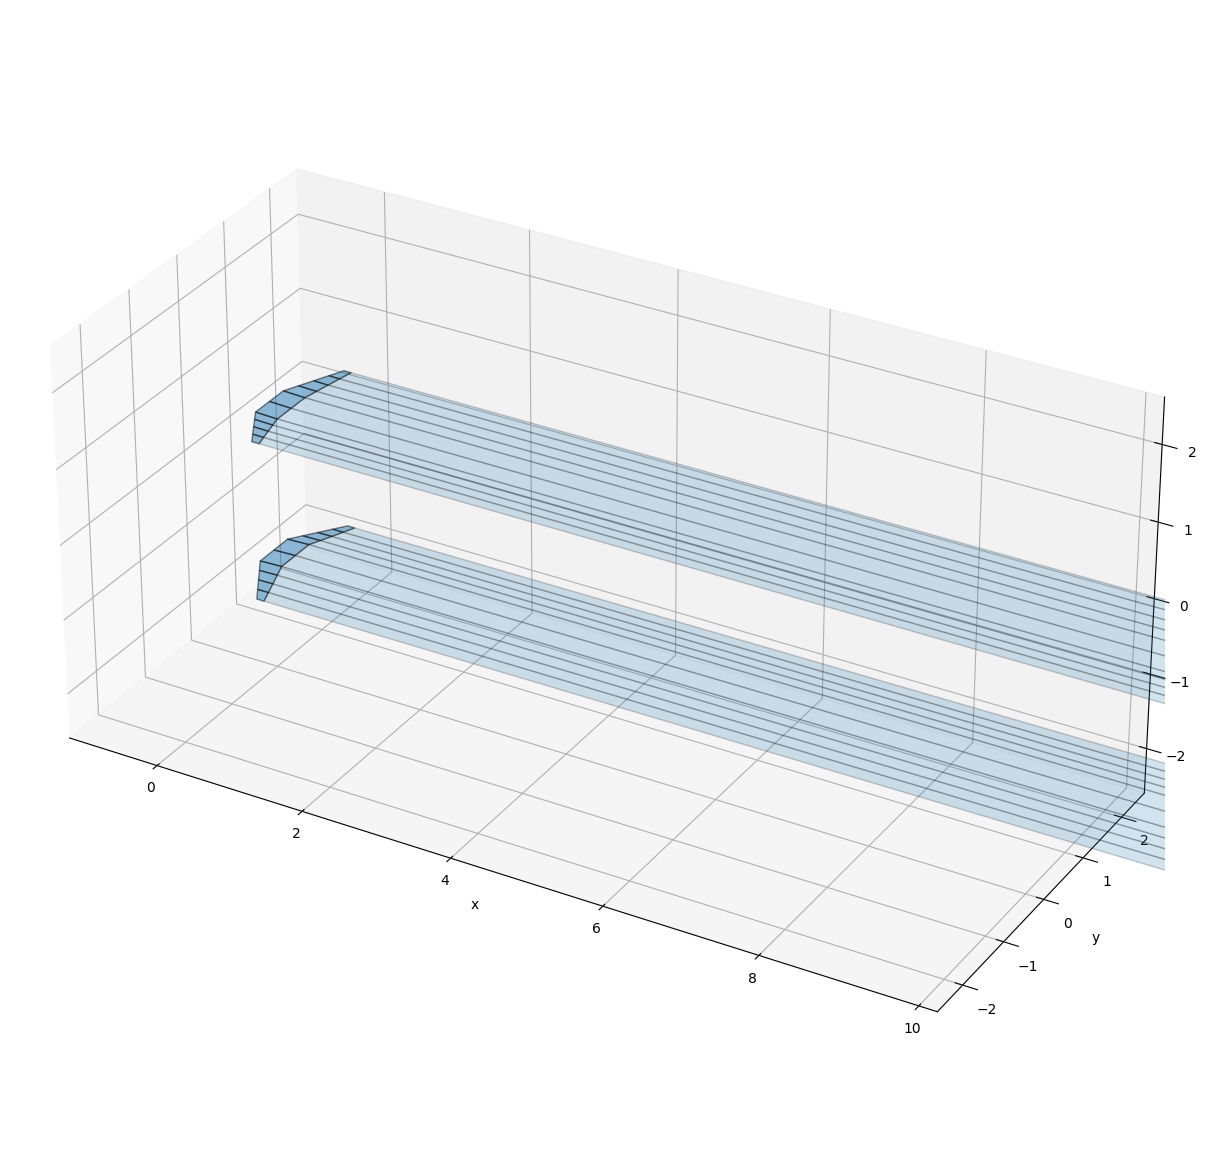

In [6]:
#> Build geometry
ac, cp, ee, rr, nor = build_wing_geometry(acs, chords, alphas, nspans, sym=False)

#> Wake
ee_wake, rr_wake, ite_wake = build_prescribed_wake(ee, rr, dir=wake_dir, length=wake_len)

#> Ground effect
ground_effect = True  # True
if ( ground_effect ):
    ac, cp, ee, rr, nor, ee_wake, rr_wake, ite_wake = \
        build_ground_effect_geometry(ac, cp, ee, rr, nor, ee_wake, rr_wake, ite_wake )

# print("ac:\n", ac)
# print("cp:\n", cp)

#> Plot Quad elements in a 3-dimensional plot
rr_plot, ee_plot, rr_wake_plot, ee_wake_plot = rr.copy(), ee.copy(), rr_wake.copy(), ee_wake.copy()
verts = [ [ rr_plot.T.tolist()[int(i)] for i in p ] for p in ee_plot.T.tolist() ]
verts_wake = [ [ rr_wake_plot.T.tolist()[int(i)] for i in p ] for p in ee_wake_plot.T.tolist() ]

#  print(verts_wake)

fig = plt.figure(figsize=(15, 15))
ax = plt.axes(projection='3d')
# ax.scatter3D(rr[0,:], rr[1,:], rr[2,:])
ax.add_collection3d(Poly3DCollection(verts, alpha=.5, edgecolor='black'), )
ax.add_collection3d(Poly3DCollection(verts_wake, alpha=.2, edgecolor='black'), )
# ax.scatter3D(ac[0,:], ac[1,:], ac[2,:], color='black')
# ax.scatter3D(cp[0,:], cp[1,:], cp[2,:], color='red')
# ax.scatter3D(rr_wake[0,:], rr_wake[1,:], rr_wake[2,:], color='blue')
# ax.quiver(cp[0,:],cp[1,:],cp[2,:], nor[0,:], nor[1,:], nor[2,:], length=.2, )
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_xlim([-1, 10])
ax.set_ylim([-2.5, 2.5])
ax.set_zlim([-2.5, 2.5])
ax.set_aspect('equal')
plt.show()

### Linear system

In [7]:
#> Test induce velocity
# cp = np.array([0., 0., 0.])
# r1 = np.array([-1., 1., 0.])
# r2 = np.array([ 1., 1., 0.])

# vel = induced_velocity_line(r1, r2, cp)
# print(vel)

#> Build linear system
A, b = build_weissinger_ls(ee, rr, cp, nor, ee_wake, rr_wake, ite_wake, vel_infty)

#> Solve linear system
gam = np.linalg.solve(A, b)

print(gam)

[0.00439347 0.00915658 0.01447456 0.01957368 0.02368887 0.02368887
 0.01957368 0.01447456 0.00915658 0.00439347 0.00439347 0.00915658
 0.01447456 0.01957368 0.02368887 0.02368887 0.01957368 0.01447456
 0.00915658 0.00439347]


## Post-processing and results

### Loads

[0.00076886 0.0016024  0.00253305 0.00342539 0.00710666 0.00710666
 0.00342539 0.00253305 0.0016024  0.00076886 0.00076886 0.0016024
 0.00253305 0.00342539 0.00710666 0.00710666 0.00342539 0.00253305
 0.0016024  0.00076886]
[-0.9125 -0.7375 -0.5625 -0.3875 -0.15    0.15    0.3875  0.5625  0.7375
  0.9125 -0.9125 -0.7375 -0.5625 -0.3875 -0.15    0.15    0.3875  0.5625
  0.7375  0.9125]
spans:  [0.175 0.175 0.175 0.175 0.3   0.3   0.175 0.175 0.175 0.175 0.175 0.175
 0.175 0.175 0.3   0.3   0.175 0.175 0.175 0.175]
chord:  [0.1 0.3 0.3 0.1]
Surface:  0.45980827525107937
Lift:  0.030872724921761067
cl  :  0.13428520791585555
cl_alpha: 220.41616662940893


/tmp/ipykernel_89753/4289016219.py:32: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


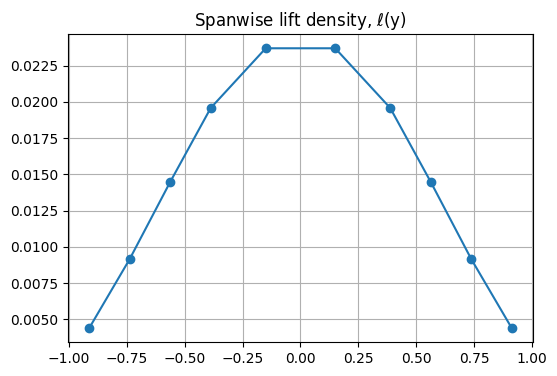

In [8]:
#> Retrive loads
# print(ee_plot.T)
rho = 1.
# dspans and dchords for very rough computation of wing surface
dspans  = np.array([ np.abs(rr[1, ie[0]] - rr[1, ie[1]]) for ie in ee_plot.T ])
dchords = np.array([ .5 * np.abs(-rr[0, ie[0]] - rr[0, ie[1]] + rr[0, ie[2]] + rr[0, ie[3]]) for ie in ee_plot.T ])

dL = rho * np.linalg.norm(vel_infty) * gam * dspans

print(dL)

n_elems = np.sum(nspans)    # retriev only real panels if ground effect is True
L = np.sum(dL[:n_elems])
yc = np.array([ .5*(rr[1,ie[0]] + rr[1,ie[1]] ) for ie in  ee_plot.T ])
print(yc)

S = np.sum(dspans[:n_elems]*dchords[:n_elems]) # chords[0] * ( acs[1,-1] - acs[1,0] )
alpha_rad = alpha * np.pi / 180.

print("spans: ", dspans)
print("chord: ", chords)
print("Surface: ", S)

print("Lift: ", L)
print("cl  : ", L / ( .5 * rho * S * np.linalg.norm(vel_infty)**2 ))
print("cl_alpha:", L / ( .5 * rho * S * np.linalg.norm(vel_infty)**2 ) / alpha_rad)

fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(yc[:n_elems], dL[:n_elems] / dspans[:n_elems], 'o-')
ax.grid()
ax.set_title('Spanwise lift density, $\ell$(y)')
fig.show()

### Velocity and pressure at ground

In [9]:
#> Evaluate velocity and pressure in desired points (probe points)
xarray = np.linspace(-10, 20, 30)
yarray = np.linspace(-5, 5, 20)
zarray = np.linspace( 0, 0, 1)

# print(xarray)
# print(yarray)
# print(zarray)

XX, YY = np.meshgrid(xarray, yarray)
UU, VV, WW = .0*XX, .0*XX, .0*XX

for ix in np.arange(np.shape(XX)[0]):
    for iy in np.arange(np.shape(XX)[1]):
        rr_probe = np.array([ XX[ix,iy], YY[ix,iy], .0 ])

        for j in np.arange(np.shape(ee)[1]):
            for l in np.arange(4):
                r1 = rr[:, ee[  l  % 4,j]]
                r2 = rr[:, ee[(l+1)% 4,j]]
                vel = induced_velocity_line(r1, r2, rr_probe)

                UU[ix,iy] += vel[0]
                VV[ix,iy] += vel[1]
                WW[ix,iy] += vel[2]

        for j in np.arange(np.shape(ee_wake)[1]):
            for l in np.arange(4):
                r1 = rr_wake[:, ee_wake[  l  % 4,j]]
                r2 = rr_wake[:, ee_wake[(l+1)% 4,j]]
                vel = induced_velocity_line(r1, r2, rr_probe)

                UU[ix,iy] += vel[0]
                VV[ix,iy] += vel[1]
                WW[ix,iy] += vel[2]

        UU[ix,iy] += vel_infty[0]
        VV[ix,iy] += vel_infty[1]
        WW[ix,iy] += vel_infty[2]


In [10]:
#> Pressure, using Bernoulli
PP = - rho * np.linalg.norm(vel_infty) * ( UU**2 + VV**2 + WW**2 ) / 2. + .5 * rho * np.linalg.norm(vel_infty)**2



max WW:  9.71445146547012e-17


/tmp/ipykernel_89753/162280788.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_89753/162280788.py:20: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_89753/162280788.py:30: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


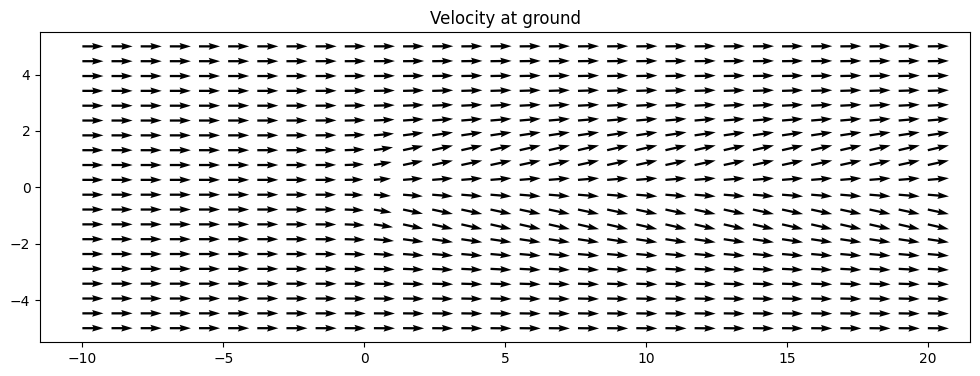

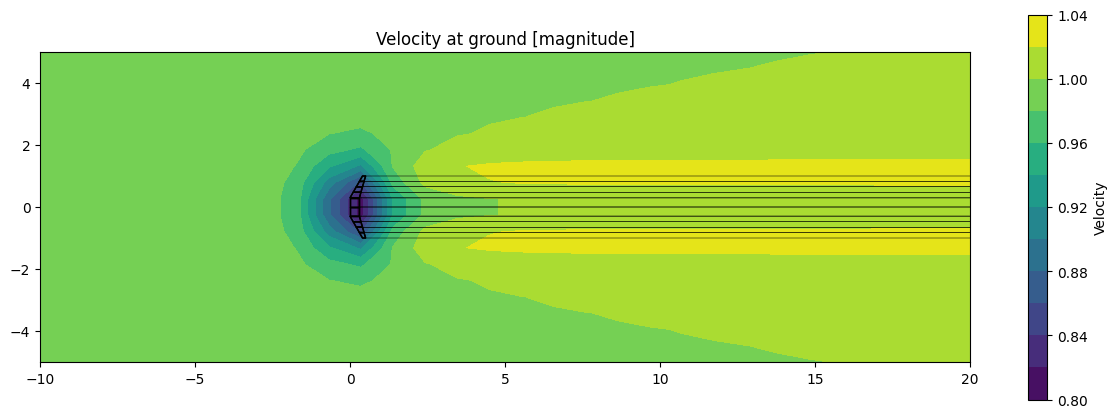

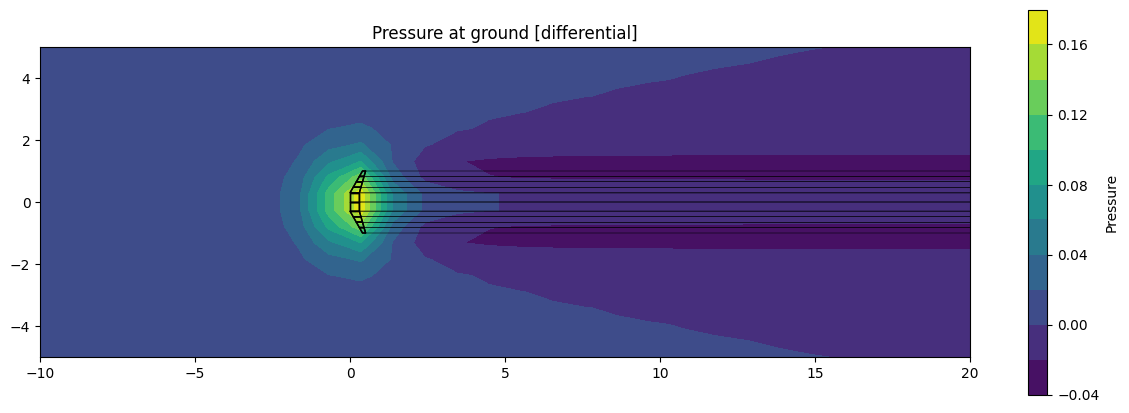

In [11]:
print("max WW: ", np.max(WW))

fig, ax = plt.subplots(1,1, figsize=(12, 5))
ax.quiver(XX, YY, UU, VV,)
ax.set_aspect('equal') # Call set_aspect on the axes object
ax.set_title('Velocity at ground')
fig.show()

verts_2d = [ [ r[:2] for r in e ] for e in verts ]
verts_wake_2d = [ [ r[:2] for r in e ] for e in verts_wake ]

fig, ax = plt.subplots(1,1, figsize=(15, 5))
cf = ax.contourf(XX, YY, np.sqrt(UU**2 + VV**2), 10)
ax.add_collection(PolyCollection(verts_2d, alpha=1., facecolor='none', edgecolor='black'), )
ax.add_collection(PolyCollection(verts_wake_2d, alpha=1., facecolor='none', edgecolor='black', linewidths=.2), )
ax.set_aspect('equal') # Call set_aspect on the axes object
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Velocity')
ax.set_title('Velocity at ground [magnitude]')
fig.show()

fig, ax = plt.subplots(1,1, figsize=(15, 5))
cf = ax.contourf(XX, YY, PP, 10)
ax.add_collection(PolyCollection(verts_2d, alpha=1., facecolor='none', edgecolor='black'), )
ax.add_collection(PolyCollection(verts_wake_2d, alpha=1., facecolor='None', edgecolor='black', linewidths=.2), )
ax.set_aspect('equal') # Call set_aspect on the axes object
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Pressure')
ax.set_title('Pressure at ground [differential]')
fig.show()

### Local pressure at ground along a line

/tmp/ipykernel_89753/1289699379.py:35: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


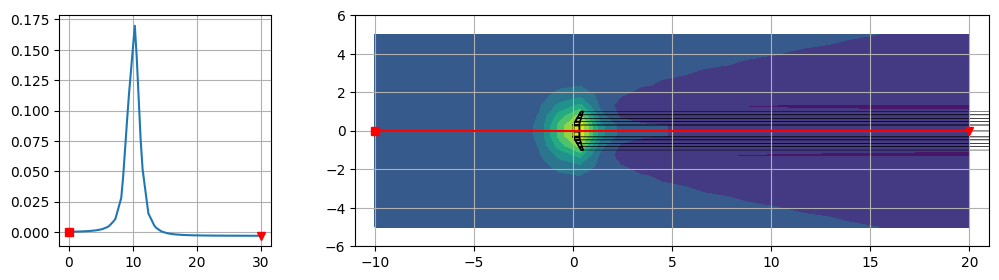

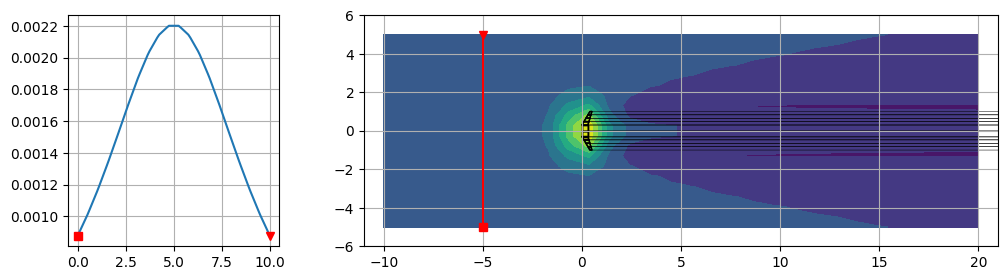

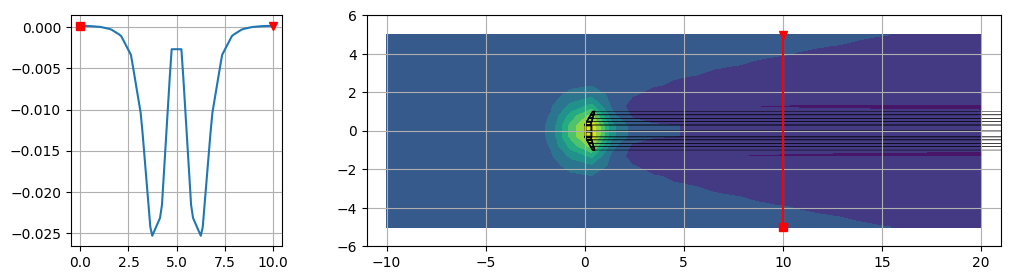

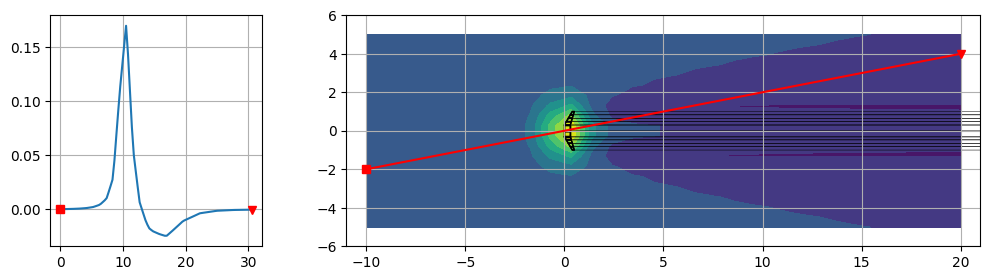

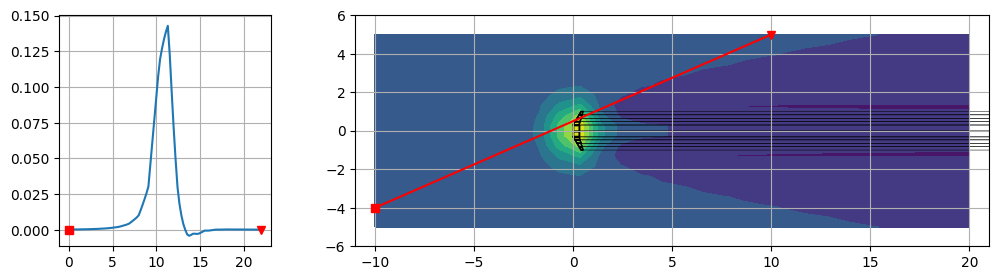

In [12]:
from scipy.interpolate import RegularGridInterpolator

line_extremes = [
    { 'x0': -10., 'y0':   0., 'x1': 20., 'y1':  0. },
    { 'x0':  -5., 'y0':  -5., 'x1': -5., 'y1':  5. },
    { 'x0':  10., 'y0':  -5., 'x1': 10., 'y1':  5. },
    { 'x0': -10., 'y0':  -2., 'x1': 20., 'y1':  4. },
    { 'x0': -10., 'y0':  -4., 'x1': 10., 'y1':  5. },
]

n_points = 100

for iline in line_extremes:
    # . Generate sampling points along the line
    xs = np.linspace(iline['x0'], iline['x1'], n_points)
    ys = np.linspace(iline['y0'], iline['y1'], n_points)
    ds = np.sqrt( ( xs[1:] - xs[0:-1] )**2 + ( ys[1:] - ys[:-1] )**2 )
    ss = np.cumsum(ds);  ss = np.insert(ss, 0, 0)
    points = np.vstack([ys, xs]).T  # IMPORTANT: order = (y, x)

    interp = RegularGridInterpolator( (yarray, xarray), PP, method='linear', bounds_error=False, fill_value=None )
    p_line = interp(points)

    fig, ax = plt.subplots(1,2, figsize=(12, 3), gridspec_kw={'width_ratios': [1, 3]})
    ax[0].plot(ss, p_line)
    ax[0].plot(ss[0], p_line[0], 's', color='red');  ax[0].plot(ss[-1], p_line[-1], 'v', color='red');
    ax[1].contourf(XX, YY, PP)
    ax[1].plot(xs, ys, color='red')
    ax[1].plot(xs[0], ys[0], 's', color='red');  ax[1].plot(xs[-1], ys[-1], 'v', color='red');
    ax[1].add_collection(PolyCollection(verts_2d, alpha=1., facecolor='none', edgecolor='black'), )
    ax[1].add_collection(PolyCollection(verts_wake_2d, alpha=1., facecolor='None', edgecolor='black', linewidths=.2), )
    ax[1].set_xlim(np.min(XX)-1, np.max(XX)+1)
    ax[1].set_ylim(np.min(YY)-1, np.max(YY)+1)
    ax[0].grid();  ax[1].grid()
    fig.show()

### Trefftz-like plane

In [13]:
#> Wake ~ "Trefftz"-like plane
xw = 10
xarray = np.linspace(xw,xw,  1)
yarray = np.linspace(-2, 2, 15)
zarray = np.linspace( 0, 2,  8)

YY, ZZ = np.meshgrid(yarray, zarray)

UU, VV, WW = .0*YY, .0*YY, .0*YY

for iy in np.arange(np.shape(YY)[0]):
    for iz in np.arange(np.shape(YY)[1]):
        rr_probe = np.array([ xw, YY[iy,iz], ZZ[iy,iz] ])

        for j in np.arange(np.shape(ee)[1]):
            for l in np.arange(4):
                r1 = rr[:, ee[  l  % 4,j]]
                r2 = rr[:, ee[(l+1)% 4,j]]
                vel = induced_velocity_line(r1, r2, rr_probe)

                UU[iy,iz] += vel[0]
                VV[iy,iz] += vel[1]
                WW[iy,iz] += vel[2]

        for j in np.arange(np.shape(ee_wake)[1]):
            for l in np.arange(4):
                r1 = rr_wake[:, ee_wake[  l  % 4,j]]
                r2 = rr_wake[:, ee_wake[(l+1)% 4,j]]
                vel = induced_velocity_line(r1, r2, rr_probe)

                UU[iy,iz] += vel[0]
                VV[iy,iz] += vel[1]
                WW[iy,iz] += vel[2]

        UU[iy,iz] += vel_infty[0]
        VV[iy,iz] += vel_infty[1]
        WW[iy,iz] += vel_infty[2]



/tmp/ipykernel_89753/2078332749.py:5: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


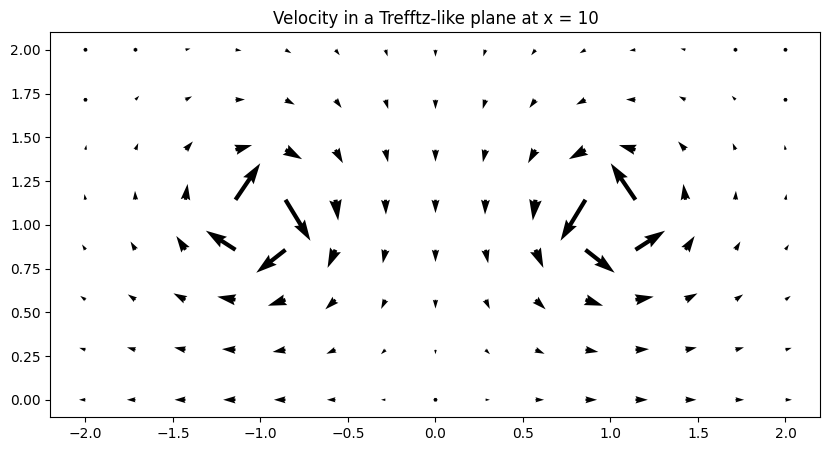

In [14]:

fig, ax = plt.subplots(1,1, figsize=(12, 5))
ax.quiver(YY, ZZ, VV, WW, scale=15)
ax.set_aspect('equal') # Call set_aspect on the axes object
ax.set_title(f"Velocity in a Trefftz-like plane at x = {xw}")
fig.show()